# Per-Class Feature Importance Analysis

### Import Libraries and Setup

In [8]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set up paths
data_folder = r"C:\Users\AGFirass\Documents\GitHub\Transformer-Based-DDoS-Detection\data\01-12\flow-level-parquets\subset-parquets-12k"

print("Libraries imported successfully!")
print(f"Data folder: {data_folder}")

Libraries imported successfully!
Data folder: C:\Users\AGFirass\Documents\GitHub\Transformer-Based-DDoS-Detection\data\01-12\flow-level-parquets\subset-parquets-12k


### Load and Inspect Data Files

In [9]:
# Get all parquet files
parquet_files = [f for f in os.listdir(data_folder) if f.endswith('.parquet')]
print(f"Found {len(parquet_files)} parquet files:")

file_info = {}
for file in parquet_files:
    file_path = os.path.join(data_folder, file)
    df_temp = pd.read_parquet(file_path)
    class_name = file.replace('.parquet', '')
    file_info[class_name] = {
        'file': file,
        'shape': df_temp.shape,
        'label': df_temp['Label'].unique()[0] if 'Label' in df_temp.columns else 'No Label'
    }
    print(f"  {file}: {df_temp.shape} - Label: {file_info[class_name]['label']}")

print(f"\nTotal classes: {len(file_info)}")

Found 12 parquet files:
  benign.parquet: (12000, 88) - Label: No Label
  DrDoS_DNS.parquet: (12000, 88) - Label: No Label
  DrDoS_LDAP.parquet: (12000, 88) - Label: No Label
  DrDoS_MSSQL.parquet: (12000, 88) - Label: No Label
  DrDoS_NetBIOS.parquet: (12000, 88) - Label: No Label
  DrDoS_NTP.parquet: (12000, 88) - Label: No Label
  DrDoS_SNMP.parquet: (12000, 88) - Label: No Label
  DrDoS_SSDP.parquet: (12000, 88) - Label: No Label
  DrDoS_UDP.parquet: (12000, 88) - Label: No Label
  Syn.parquet: (12000, 88) - Label: No Label
  TFTP.parquet: (12000, 88) - Label: No Label
  UDPLag.parquet: (12000, 88) - Label: No Label

Total classes: 12


### Data Preprocessing Function

In [10]:
def preprocess_single_file(file_path):
    """
    Preprocess a single parquet file:
    - Load data
    - Handle missing values in 'Flow Bytes/s'
    - Drop unnecessary columns
    - Return processed dataframe
    """
    # Load data
    df = pd.read_parquet(file_path)
    print(f"Loaded {file_path}: {df.shape}")

    # Check what columns actually exist
    print(f"  - Columns with object dtype: {df.select_dtypes(include=['object']).columns.tolist()}")

    # Handle missing values in 'Flow Bytes/s'
    if 'Flow Bytes/s' in df.columns:
        missing_count = df['Flow Bytes/s'].isnull().sum()
        if missing_count > 0:
            print(f"  - Imputing {missing_count} missing values in 'Flow Bytes/s' with median")
            df['Flow Bytes/s'] = df['Flow Bytes/s'].fillna(df['Flow Bytes/s'].median())

    # Columns to drop - check which ones actually exist
    cols_to_drop = ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'SimillarHTTP', 'Unnamed: 0', 'Label']
    existing_cols_to_drop = [col for col in cols_to_drop if col in df.columns]

    if existing_cols_to_drop:
        print(f"  - Dropping columns: {existing_cols_to_drop}")
        df.drop(columns=existing_cols_to_drop, inplace=True)

    # Drop ALL remaining object columns (they cause issues with XGBoost)
    object_columns = df.select_dtypes(include=['object']).columns.tolist()
    if object_columns:
        print(f"  - Dropping remaining object columns: {object_columns}")
        df.drop(columns=object_columns, inplace=True)

    # Handle inf values
    print("  - Handling infinite values...")
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(df.median(numeric_only=True), inplace=True)

    # Ensure all remaining columns are numeric
    print(f"  - Data types after cleaning: {df.dtypes.value_counts().to_dict()}")

    print(f"  - Final shape: {df.shape}")
    return df

# Test preprocessing on first file
test_file = os.path.join(data_folder, parquet_files[0])
test_df = preprocess_single_file(test_file)
print(f"\nTest preprocessing completed. Columns: {len(test_df.columns)}")
print(f"Remaining column types: {test_df.dtypes.value_counts().to_dict()}")

Loaded C:\Users\AGFirass\Documents\GitHub\Transformer-Based-DDoS-Detection\data\01-12\flow-level-parquets\subset-parquets-12k\benign.parquet: (12000, 88)
  - Columns with object dtype: ['Flow ID', ' Source IP', ' Destination IP', ' Timestamp', 'SimillarHTTP', ' Label']
  - Imputing 34 missing values in 'Flow Bytes/s' with median
  - Dropping columns: ['Flow ID', 'SimillarHTTP', 'Unnamed: 0']
  - Dropping remaining object columns: [' Source IP', ' Destination IP', ' Timestamp', ' Label']
  - Handling infinite values...
  - Data types after cleaning: {dtype('float64'): 45, dtype('int64'): 36}
  - Final shape: (12000, 81)

Test preprocessing completed. Columns: 81
Remaining column types: {dtype('float64'): 45, dtype('int64'): 36}


### Load and Combine All Data

In [11]:
# Load and preprocess all files
all_data = []
class_labels = {}

print("Loading and preprocessing all files...")
for i, (class_name, info) in enumerate(file_info.items()):
    file_path = os.path.join(data_folder, info['file'])
    df = preprocess_single_file(file_path)

    # Extract class name from filename (remove .parquet extension)
    clean_class_name = info['file'].replace('.parquet', '')

    # Store class label mapping
    class_labels[clean_class_name] = i

    # Add class information - create the label from filename
    df['class_name'] = clean_class_name
    df['class_id'] = i

    all_data.append(df)
    print(f"Processed {clean_class_name}: {df.shape}")

print(f"\nAll files processed. Total datasets: {len(all_data)}")
print("Class mapping:")
for class_name, class_id in class_labels.items():
    print(f"  {class_id}: {class_name}")

# Verify all datasets have the same columns (except class info)
first_df_cols = set(all_data[0].drop(columns=['class_name', 'class_id']).columns)
for i, df in enumerate(all_data[1:], 1):
    current_cols = set(df.drop(columns=['class_name', 'class_id']).columns)
    if current_cols != first_df_cols:
        print(f"WARNING: Dataset {i} has different columns!")
        print(f"  Missing: {first_df_cols - current_cols}")
        print(f"  Extra: {current_cols - first_df_cols}")
    else:
        print(f"✓ Dataset {i} columns match")

Loading and preprocessing all files...
Loaded C:\Users\AGFirass\Documents\GitHub\Transformer-Based-DDoS-Detection\data\01-12\flow-level-parquets\subset-parquets-12k\benign.parquet: (12000, 88)
  - Columns with object dtype: ['Flow ID', ' Source IP', ' Destination IP', ' Timestamp', 'SimillarHTTP', ' Label']
  - Imputing 34 missing values in 'Flow Bytes/s' with median
  - Dropping columns: ['Flow ID', 'SimillarHTTP', 'Unnamed: 0']
  - Dropping remaining object columns: [' Source IP', ' Destination IP', ' Timestamp', ' Label']
  - Handling infinite values...
  - Data types after cleaning: {dtype('float64'): 45, dtype('int64'): 36}
  - Final shape: (12000, 81)
Processed benign: (12000, 83)
Loaded C:\Users\AGFirass\Documents\GitHub\Transformer-Based-DDoS-Detection\data\01-12\flow-level-parquets\subset-parquets-12k\DrDoS_DNS.parquet: (12000, 88)
  - Columns with object dtype: ['Flow ID', ' Source IP', ' Destination IP', ' Timestamp', 'SimillarHTTP', ' Label']
  - Dropping columns: ['Flow ID

### Create Combined Dataset

In [12]:
# Combine all data
print("Combining all datasets...")
combined_df = pd.concat(all_data, ignore_index=True)
print(f"Combined dataset shape: {combined_df.shape}")

# Check class distribution
class_distribution = combined_df['class_name'].value_counts()
print(f"\nClass distribution:")
print(class_distribution)

# Prepare features and target
X_combined = combined_df.drop(columns=['class_name', 'class_id'])
y_combined = combined_df['class_id']

print(f"\nFeature matrix shape: {X_combined.shape}")
print(f"Target vector shape: {y_combined.shape}")
print(f"Feature columns: {len(X_combined.columns)}")

# Final data type check
print(f"\nFinal data types in X_combined:")
print(X_combined.dtypes.value_counts())

# Check for any remaining non-numeric columns
non_numeric = X_combined.select_dtypes(include=['object', 'category']).columns
if len(non_numeric) > 0:
    print(f"WARNING: Non-numeric columns found: {non_numeric.tolist()}")
    print("Dropping them...")
    X_combined = X_combined.drop(columns=non_numeric)
    print(f"New shape after dropping non-numeric: {X_combined.shape}")
else:
    print("✓ All features are numeric - ready for XGBoost!")

print(f"Final feature names sample: {list(X_combined.columns[:5])}")

Combining all datasets...
Combined dataset shape: (144000, 83)

Class distribution:
class_name
benign           12000
DrDoS_DNS        12000
DrDoS_LDAP       12000
DrDoS_MSSQL      12000
DrDoS_NetBIOS    12000
DrDoS_NTP        12000
DrDoS_SNMP       12000
DrDoS_SSDP       12000
DrDoS_UDP        12000
Syn              12000
TFTP             12000
UDPLag           12000
Name: count, dtype: int64

Feature matrix shape: (144000, 81)
Target vector shape: (144000,)
Feature columns: 81

Final data types in X_combined:
float64    45
int64      36
Name: count, dtype: int64
✓ All features are numeric - ready for XGBoost!
Final feature names sample: [' Source Port', ' Destination Port', ' Protocol', ' Flow Duration', ' Total Fwd Packets']


### Binary Classification Approach - Per Class vs Rest

In [15]:
def train_binary_classifier_for_class(X_data, y_data, target_class_id, class_name):
    """
    Train a binary classifier for one class vs all others
    """
    # Create binary target (1 for target class, 0 for others)
    y_binary = (y_data == target_class_id).astype(int)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_binary, test_size=0.2, stratify=y_binary, random_state=42
    )

    # Train XGBoost binary classifier
    model = xgb.XGBClassifier(
        objective='binary:logistic',
        max_depth=6,
        learning_rate=0.1,
        n_estimators=200,
        tree_method='hist',
        device='cuda',
        random_state=42,
        verbosity=0
    )

    model.fit(X_train, y_train)

    # Evaluate
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    # Get feature importance
    importance = model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'feature': X_data.columns,
        'importance': importance
    }).sort_values('importance', ascending=False)

    return {
        'model': model,
        'accuracy': accuracy,
        'feature_importance': feature_importance_df,
        'class_name': class_name,
        'class_id': target_class_id
    }

# Test with first class
print("Testing binary classification approach...")
first_class_name = list(class_labels.keys())[0]
first_class_id = class_labels[first_class_name]

result = train_binary_classifier_for_class(X_combined, y_combined, first_class_id, first_class_name)
print(f"Binary classifier for '{first_class_name}' - Accuracy: {result['accuracy']:.4f}")
print(f"Top 5 features for {first_class_name}:")
print(result['feature_importance'].head())

Testing binary classification approach...
Binary classifier for 'benign' - Accuracy: 1.0000
Top 5 features for benign:
               feature  importance
80             Inbound    0.811272
0          Source Port    0.105345
1     Destination Port    0.029501
72         Active Mean    0.026233
40   Min Packet Length    0.003551


### Train Binary Classifiers for All Classes

In [17]:
# Train binary classifiers for all classes
print("Training binary classifiers for all classes...")
print("="*60)

all_results = {}

for class_name, class_id in class_labels.items():
    print(f"\nTraining binary classifier for: {class_name} (ID: {class_id})")

    result = train_binary_classifier_for_class(X_combined, y_combined, class_id, class_name)
    all_results[class_name] = result

    print(f"  Accuracy: {result['accuracy']:.4f}")
    print(f"  Top 5 features: {', '.join(result['feature_importance'].head(5)['feature'].tolist())}")

print(f"\nCompleted training for {len(all_results)} classes!")

Training binary classifiers for all classes...

Training binary classifier for: benign (ID: 0)
  Accuracy: 1.0000
  Top 5 features:  Inbound,  Source Port,  Destination Port, Active Mean,  Min Packet Length

Training binary classifier for: DrDoS_DNS (ID: 1)
  Accuracy: 0.9913
  Top 5 features:  act_data_pkt_fwd,  Fwd Packet Length Mean,  Packet Length Mean,  Source Port, Fwd IAT Total

Training binary classifier for: DrDoS_LDAP (ID: 2)
  Accuracy: 0.9703
  Top 5 features:  Average Packet Size,  Min Packet Length,  Fwd Packet Length Min,  Source Port, Fwd IAT Total

Training binary classifier for: DrDoS_MSSQL (ID: 3)
  Accuracy: 0.9514
  Top 5 features:  Average Packet Size,  Source Port, Flow Bytes/s,  min_seg_size_forward,  Flow IAT Min

Training binary classifier for: DrDoS_NetBIOS (ID: 4)
  Accuracy: 0.9947
  Top 5 features:  Average Packet Size,  Source Port,  Inbound,  Fwd Packet Length Max,  Total Fwd Packets

Training binary classifier for: DrDoS_NTP (ID: 5)
  Accuracy: 0.9971
 

### Analyze Per-Class Feature Importance

In [18]:
# Analyze and compare feature importance across classes
print("PER-CLASS FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Create a comprehensive comparison
feature_names = X_combined.columns
comparison_df = pd.DataFrame({'feature': feature_names})

# Add importance for each class
for class_name, result in all_results.items():
    importance_dict = dict(zip(result['feature_importance']['feature'],
                              result['feature_importance']['importance']))

    # Align with all features (some might have 0 importance)
    importance_values = [importance_dict.get(feature, 0) for feature in feature_names]
    comparison_df[f'{class_name}_importance'] = importance_values

# Calculate statistics
comparison_df['mean_importance'] = comparison_df.iloc[:, 1:].mean(axis=1)
comparison_df['std_importance'] = comparison_df.iloc[:, 1:].std(axis=1)
comparison_df['max_importance'] = comparison_df.iloc[:, 1:].max(axis=1)

# Sort by mean importance
comparison_df = comparison_df.sort_values('mean_importance', ascending=False)

print("Top 15 Features by Average Importance Across All Classes:")
print(comparison_df[['feature', 'mean_importance', 'std_importance', 'max_importance']].head(15))

PER-CLASS FEATURE IMPORTANCE ANALYSIS
Top 15 Features by Average Importance Across All Classes:
                    feature  mean_importance  std_importance  max_importance
54      Average Packet Size         0.176705        0.242530        0.648824
49           ACK Flag Count         0.136122        0.299666        0.809994
71     min_seg_size_forward         0.092922        0.213333        0.754493
40        Min Packet Length         0.076221        0.141920        0.475352
80                  Inbound         0.075753        0.222261        0.811272
70         act_data_pkt_fwd         0.074709        0.190805        0.679518
10   Fwd Packet Length Mean         0.053382        0.123224        0.430751
0               Source Port         0.051700        0.052250        0.192280
42       Packet Length Mean         0.043344        0.069095        0.221929
41        Max Packet Length         0.030558        0.078469        0.290082
9     Fwd Packet Length Min         0.027011        0.043

### Visualize Per-Class Feature Importance

Creating feature importance heatmap...


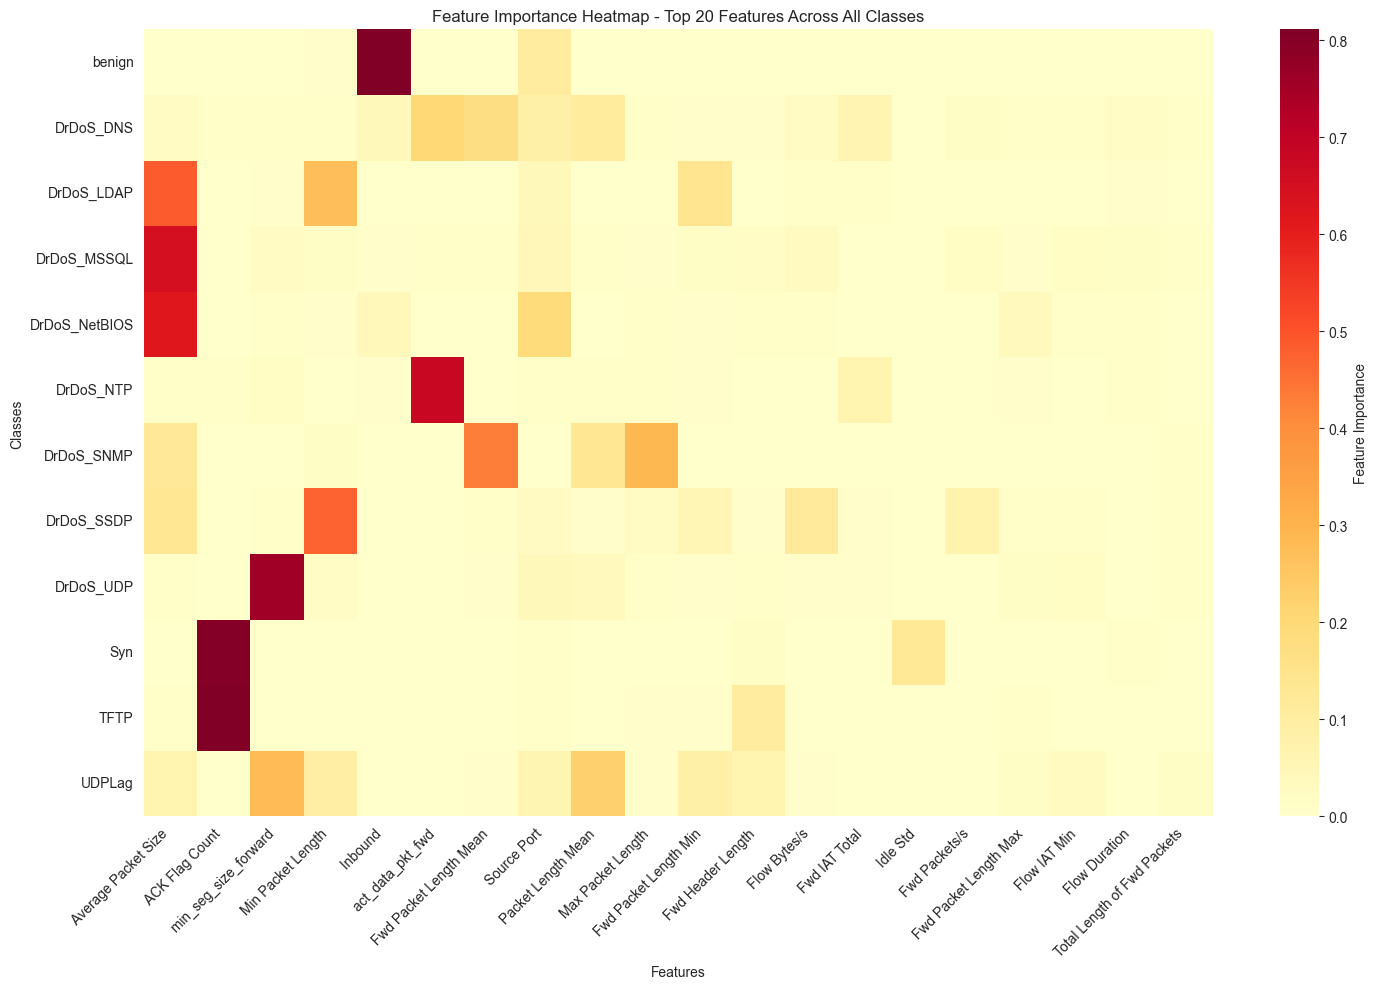

Heatmap created successfully!


In [19]:
# Create heatmap of top features across classes
print("Creating feature importance heatmap...")

# Select top N features for visualization
top_n = 20
top_features = comparison_df.head(top_n)['feature'].tolist()

# Create matrix for heatmap
heatmap_data = []
class_names = []

for class_name in class_labels.keys():
    class_names.append(class_name)
    class_importances = []

    for feature in top_features:
        importance = comparison_df[comparison_df['feature'] == feature][f'{class_name}_importance'].values[0]
        class_importances.append(importance)

    heatmap_data.append(class_importances)

# Create heatmap
plt.figure(figsize=(15, 10))
heatmap_array = np.array(heatmap_data)

sns.heatmap(heatmap_array,
            xticklabels=top_features,
            yticklabels=class_names,
            annot=False,
            cmap='YlOrRd',
            cbar_kws={'label': 'Feature Importance'})

plt.title(f'Feature Importance Heatmap - Top {top_n} Features Across All Classes')
plt.xlabel('Features')
plt.ylabel('Classes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Heatmap created successfully!")

### Individual Class Analysis

In [21]:
# Detailed analysis for each class
def analyze_single_class(class_name, result, top_n=10):
    """Analyze feature importance for a single class"""
    print(f"\n{'='*20} {class_name.upper()} {'='*20}")
    print(f"Binary Classification Accuracy: {result['accuracy']:.4f}")

    top_features = result['feature_importance'].head(top_n)
    print(f"\nTop {top_n} Most Important Features:")

    for i, (_, row) in enumerate(top_features.iterrows(), 1):
        print(f"{i:2d}. {row['feature']:35s} {row['importance']:.6f}")

    # Feature importance statistics for this class
    importance_values = result['feature_importance']['importance']
    print(f"\nFeature Importance Statistics:")
    print(f"  Mean:     {importance_values.mean():.6f}")
    print(f"  Std:      {importance_values.std():.6f}")
    print(f"  Max:      {importance_values.max():.6f}")
    print(f"  Min:      {importance_values.min():.6f}")
    print(f"  Non-zero: {(importance_values > 0).sum()}")

    return top_features

# Analyze first few classes in detail
# classes_to_analyze = list(class_labels.keys())[:3]  # Analyze first 3 classes
classes_to_analyze = list(class_labels.keys())

detailed_results = {}
for class_name in classes_to_analyze:
    detailed_results[class_name] = analyze_single_class(class_name, all_results[class_name])


==================== BENIGN ====================
Binary Classification Accuracy: 1.0000

Top 10 Most Important Features:
 1.  Inbound                            0.811272
 2.  Source Port                        0.105345
 3.  Destination Port                   0.029501
 4. Active Mean                         0.026233
 5.  Min Packet Length                  0.003551
 6.  Active Min                         0.002865
 7. Init_Win_bytes_forward              0.002800
 8.  Total Backward Packets             0.002783
 9.  Fwd Packet Length Mean             0.001878
10.  ACK Flag Count                     0.001604

Feature Importance Statistics:
  Mean:     0.012346
  Std:      0.090728
  Max:      0.811272
  Min:      0.000000
  Non-zero: 45

==================== DRDOS_DNS ====================
Binary Classification Accuracy: 0.9913

Top 10 Most Important Features:
 1.  act_data_pkt_fwd                   0.205029
 2.  Fwd Packet Length Mean             0.174977
 3.  Packet Length Mean           

### Save Per-Class Feature Importance Results

In [22]:
# Save results for each class
print("Saving per-class feature importance results...")

# Create results directory
results_dir = "per_class_feature_importance_results"
os.makedirs(results_dir, exist_ok=True)

# Save individual class results
for class_name, result in all_results.items():
    # Save feature importance
    filename = f"{results_dir}/{class_name}_feature_importance.csv"
    result['feature_importance'].to_csv(filename, index=False)
    print(f"✓ Saved {class_name} feature importance to {filename}")

# Save comprehensive comparison
comparison_filename = f"{results_dir}/all_classes_comparison.csv"
comparison_df.to_csv(comparison_filename, index=False)
print(f"✓ Saved comprehensive comparison to {comparison_filename}")

# Save summary statistics
summary_stats = []
for class_name, result in all_results.items():
    summary_stats.append({
        'class_name': class_name,
        'class_id': result['class_id'],
        'binary_accuracy': result['accuracy'],
        'top_feature': result['feature_importance'].iloc[0]['feature'],
        'top_feature_importance': result['feature_importance'].iloc[0]['importance'],
        'num_nonzero_features': (result['feature_importance']['importance'] > 0).sum()
    })

summary_df = pd.DataFrame(summary_stats)
summary_filename = f"{results_dir}/summary_statistics.csv"
summary_df.to_csv(summary_filename, index=False)
print(f"✓ Saved summary statistics to {summary_filename}")

print(f"\nAll results saved to '{results_dir}' directory!")

Saving per-class feature importance results...
✓ Saved benign feature importance to per_class_feature_importance_results/benign_feature_importance.csv
✓ Saved DrDoS_DNS feature importance to per_class_feature_importance_results/DrDoS_DNS_feature_importance.csv
✓ Saved DrDoS_LDAP feature importance to per_class_feature_importance_results/DrDoS_LDAP_feature_importance.csv
✓ Saved DrDoS_MSSQL feature importance to per_class_feature_importance_results/DrDoS_MSSQL_feature_importance.csv
✓ Saved DrDoS_NetBIOS feature importance to per_class_feature_importance_results/DrDoS_NetBIOS_feature_importance.csv
✓ Saved DrDoS_NTP feature importance to per_class_feature_importance_results/DrDoS_NTP_feature_importance.csv
✓ Saved DrDoS_SNMP feature importance to per_class_feature_importance_results/DrDoS_SNMP_feature_importance.csv
✓ Saved DrDoS_SSDP feature importance to per_class_feature_importance_results/DrDoS_SSDP_feature_importance.csv
✓ Saved DrDoS_UDP feature importance to per_class_feature_imp

### Class-Specific Feature Insights

In [23]:
# Generate insights about class-specific vs common features
print("CLASS-SPECIFIC FEATURE INSIGHTS")
print("="*50)

# Find features that are highly important for specific classes
def find_class_specific_features(threshold_percentile=90):
    """Find features that are particularly important for specific classes"""

    class_specific_features = {}

    for class_name in class_labels.keys():
        # Get importance for this class
        class_importance = comparison_df[f'{class_name}_importance']

        # Find features above threshold for this class
        threshold = np.percentile(class_importance, threshold_percentile)
        important_features = comparison_df[class_importance > threshold]['feature'].tolist()

        # Check if these features are less important for other classes
        specific_features = []
        for feature in important_features:
            feature_row = comparison_df[comparison_df['feature'] == feature].iloc[0]
            class_imp = feature_row[f'{class_name}_importance']

            # Calculate how much higher this feature is for current class vs others
            other_importances = []
            for other_class in class_labels.keys():
                if other_class != class_name:
                    other_importances.append(feature_row[f'{other_class}_importance'])

            avg_other_imp = np.mean(other_importances)

            # If this class has significantly higher importance for this feature
            if class_imp > 2 * avg_other_imp and class_imp > 0.01:
                ratio = class_imp / (avg_other_imp + 1e-10)
                specific_features.append((feature, class_imp, ratio))

        # Sort by importance ratio
        specific_features.sort(key=lambda x: x[2], reverse=True)
        class_specific_features[class_name] = specific_features[:5]  # Top 5

    return class_specific_features

class_specific = find_class_specific_features()

for class_name, features in class_specific.items():
    if features:
        print(f"\n{class_name.upper()} - Class-Specific Features:")
        for i, (feature, importance, ratio) in enumerate(features, 1):
            print(f"  {i}. {feature:30s} (imp: {importance:.4f}, ratio: {ratio:.1f}x)")
    else:
        print(f"\n{class_name.upper()} - No highly specific features found")

# Find universally important features
print(f"\nUNIVERSALLY IMPORTANT FEATURES:")
print("Features important across multiple classes:")

universal_threshold = 0.01
universal_features = []

for _, row in comparison_df.head(20).iterrows():
    feature = row['feature']
    importance_counts = 0
    total_importance = 0

    for class_name in class_labels.keys():
        imp = row[f'{class_name}_importance']
        if imp > universal_threshold:
            importance_counts += 1
            total_importance += imp

    if importance_counts >= len(class_labels) * 0.5:  # Important in at least 50% of classes
        universal_features.append((feature, importance_counts, total_importance))

universal_features.sort(key=lambda x: x[2], reverse=True)

for i, (feature, count, total_imp) in enumerate(universal_features[:10], 1):
    print(f"{i:2d}. {feature:35s} (in {count}/{len(class_labels)} classes, total: {total_imp:.4f})")

print(f"\nAnalysis completed! 🎉")

CLASS-SPECIFIC FEATURE INSIGHTS

BENIGN - Class-Specific Features:
  1.  Inbound                       (imp: 0.8113, ratio: 91.3x)
  2. Active Mean                    (imp: 0.0262, ratio: 88.8x)
  3.  Destination Port              (imp: 0.0295, ratio: 13.9x)
  4.  Source Port                   (imp: 0.1053, ratio: 2.2x)

DRDOS_DNS - Class-Specific Features:
  1.  Protocol                      (imp: 0.0230, ratio: 8.0x)
  2. Fwd IAT Total                  (imp: 0.0616, ratio: 7.5x)
  3.  Fwd Packet Length Mean        (imp: 0.1750, ratio: 4.1x)
  4.  act_data_pkt_fwd              (imp: 0.2050, ratio: 3.3x)
  5.  Packet Length Mean            (imp: 0.1097, ratio: 2.9x)

DRDOS_LDAP - Class-Specific Features:
  1.  Fwd Packet Length Min         (imp: 0.1432, ratio: 8.7x)
  2.  Min Packet Length             (imp: 0.2738, ratio: 4.7x)
  3.  Average Packet Size           (imp: 0.4872, ratio: 3.3x)

DRDOS_MSSQL - Class-Specific Features:
  1.  Average Packet Size           (imp: 0.6488, ratio: 